# Анализ лояльности пользователей Яндекс Афиши

Автор: Ревизская Надежда
Дата: 6.04.2026

### Цели и задачи проекта

<font color='#777778'>Провести исследовательский анализ данных, чтобы понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно, для удержания клиентов и выявления перспективных сегментов для маркетингового воздействия.</font>

### Описание данных

<font color='#777778'>Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.
</font>

### Содержимое проекта

<font color='#777778'>**Шаг 1. Загрузка данных и знакомство с ними:**\
    - объём данных\
    - соответствие описанию\
    - пропуски\
    - типы данных\
    - другие особенности данных\
\
    \
**Шаг 2. Предобработка данных:**\
    - преобразование типов данных\
    - обработка пропусков\
    - обработка явных и неявных дубликатов\
    - добавление новых столбцов для работы\
    - промежуточный вывод\
\
    \
**Шаг 3. Исследовательский анализ данных:**\
    - Создание профиля клиента\
    - Сегментация клиентов и выявление влияющих на возврат факторов\ 
\
    \
**Шаг 4. Итоговый вывод и рекомендации**
    \
    \
</font>

---

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
!pip install sqlalchemy
!pip install psycopg2-binary
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
!pip install phik
from phik import phik_matrix

     |████████████████████████████████| 677 kB 2.6 MB/s eta 0:00:01


In [2]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [3]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [4]:
engine = create_engine(connection_string)

In [5]:
query = '''
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    (p.created_dt_msk::date - LAG(p.created_dt_msk) OVER(PARTITION BY p.user_id ORDER BY p.created_dt_msk)::date)::INTEGER AS days_since_prev,
    e.event_id,
    e.event_name_code AS event_name,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p 
INNER JOIN afisha.events AS e ON p.event_id = e.event_id
LEFT JOIN afisha.city AS c ON e.city_id = c.city_id
LEFT JOIN afisha.regions AS r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id;
'''

In [6]:
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  event_type_main        290611 non-null  obje

In [8]:
df.head(5)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк


Датасет содержит 15 столбцов и 290611 строк, в которых содержатся данные о покупках клиентов Яндекс Афиши.
Данные соответствуют описанию.
Тип данных в столбце days_since_prev можно перевести в int.
Тип данных в столбце tickets_count можно оптимизировать.
Пропуски содержит только столбец days_since_prev.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [9]:
kz = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
kz.head(5)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [10]:
kz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [11]:
kz['data'] = pd.to_datetime(kz['data'])

In [12]:
kz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[ns]
 1   nominal  357 non-null    int64         
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 11.3+ KB


In [13]:
#Приведение выручки к единой валюте
rate = kz.set_index('data')['curs'] / 100

df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['order_dt'].map(rate))

In [14]:
df[df['currency_code'] == 'kzt'].head(10)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,revenue_rub
70,0033403583a55ed,mobile,7850214,2024-09-17,2024-09-17 16:52:06,kzt,518.10,4,20.0,559919,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,Билеты без проблем,другое,Верхоречная область,Серебрянка,98.503762
89,0040e12d70fae81,desktop,8634925,2024-09-02,2024-09-02 19:49:14,kzt,347.18,3,39.0,559476,61ec7c0e-ea0c-4a3e-a63a-09cbe1bc6177,Билеты без проблем,другое,Верхоречная область,Серебрянка,65.731589
96,0054b38b2653e6e,mobile,7625522,2024-09-09,2024-09-09 18:06:04,kzt,328.77,4,NaN,559582,524f434e-0381-4f47-9688-7c4e41961b65,Билеты без проблем,другое,Верхоречная область,Серебрянка,61.148261
277,00f4f5244501ce6,mobile,720419,2024-06-11,2024-06-11 20:15:57,kzt,22021.55,5,NaN,536826,76af4f88-c554-4e9e-9df4-1cc8aeec8959,Мой билет,концерты,Верхоречная область,Серебрянка,4380.702898
460,01370a0e9c1a7d5,desktop,5227657,2024-06-04,2024-06-04 13:28:17,kzt,7397.66,4,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,Мой билет,концерты,Шанырский регион,Широковка,1478.296591
461,01370a0e9c1a7d5,mobile,2229811,2024-06-04,2024-06-04 13:19:47,kzt,7397.66,4,0.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,Мой билет,концерты,Шанырский регион,Широковка,1478.296591
462,01370a0e9c1a7d5,mobile,2229782,2024-06-04,2024-06-04 13:17:35,kzt,3698.83,2,0.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,Мой билет,концерты,Шанырский регион,Широковка,739.148295
463,01370a0e9c1a7d5,mobile,2229753,2024-06-04,2024-06-04 13:26:32,kzt,5548.24,3,0.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,Мой билет,концерты,Шанырский регион,Широковка,1108.721444
464,01370a0e9c1a7d5,mobile,2229724,2024-06-04,2024-06-04 13:25:28,kzt,7397.66,4,0.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,Мой билет,концерты,Шанырский регион,Широковка,1478.296591
515,01370a0e9c1a7d5,mobile,2044298,2024-09-05,2024-09-05 16:15:58,kzt,361.08,4,1.0,561747,27956246-d4a5-4b76-b5db-719831c41591,Мой билет,другое,Шанырский регион,Синеводск,66.517074


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [15]:
# Создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp = df.copy() 
len(temp)

290611

In [16]:
#Преобразование типов данных
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')
df['days_since_prev'] = df['days_since_prev'].astype('Int64')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  Int64         
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  event_type_main        290611 non-null  obje

In [18]:
#Количество пропусков

df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64

In [19]:
#Доля пропусков

round(df.isna().mean()*100, 2)

user_id                  0.00
device_type_canonical    0.00
order_id                 0.00
order_dt                 0.00
order_ts                 0.00
currency_code            0.00
revenue                  0.00
tickets_count            0.00
days_since_prev          7.55
event_id                 0.00
event_name               0.00
service_name             0.00
event_type_main          0.00
region_name              0.00
city_name                0.00
revenue_rub              0.00
dtype: float64

Пропуски содержатся только в столбце days_since_prev.\
Пропуски типа MNAR, можно оставить, как есть.

In [20]:
#Проверка явных дубликатов
df.duplicated().sum()

0

In [21]:
#Проверка неявных дубликатов
print(df['device_type_canonical'].sort_values().unique())

['desktop' 'mobile']


In [22]:
print(df['currency_code'].sort_values().unique())

['kzt' 'rub']


In [23]:
print(df['service_name'].sort_values().unique())

['Crazy ticket!' 'Show_ticket' 'Билет по телефону' 'Билеты без проблем'
 'Билеты в интернете' 'Билеты в руки' 'Быстробилет' 'Быстрый кассир'
 'Весь в билетах' 'Восьмёрка' 'Вперёд!' 'Выступления.ру'
 'Городской дом культуры' 'Дом культуры' 'Дырокол' 'За билетом!'
 'Зе Бест!' 'КарандашРУ' 'Кино билет' 'Край билетов' 'Лимоны'
 'Лови билет!' 'Лучшие билеты' 'Мир касс' 'Мой билет' 'Облачко'
 'Прачечная' 'Радио ticket' 'Реестр' 'Росбилет' 'Тебе билет!' 'Телебилет'
 'Тех билет' 'Цвет и билет' 'Шоу начинается!' 'Яблоко']


In [24]:
print(df['event_type_main'].sort_values().unique())

['выставки' 'другое' 'концерты' 'спорт' 'стендап' 'театр' 'ёлки']


In [25]:
print(df['region_name'].sort_values().unique())

['Белоярская область' 'Берестовский округ' 'Берёзовская область'
 'Боровлянский край' 'Верховинская область' 'Верхозёрский край'
 'Верхоречная область' 'Ветренский регион' 'Вишнёвский край'
 'Глиногорская область' 'Голубевский округ' 'Горицветская область'
 'Горноземский регион' 'Горностепной регион' 'Дальнеземская область'
 'Дальнезорский край' 'Дубравная область' 'Залесский край'
 'Заречная область' 'Зеленоградский округ' 'Златопольский округ'
 'Золотоключевской край' 'Зоринский регион' 'Каменевский регион'
 'Каменичская область' 'Каменноозёрный край' 'Каменноярский край'
 'Каменополянский округ' 'Ключеводский округ' 'Кристаловская область'
 'Кристальная область' 'Крутоводская область' 'Крутоводский регион'
 'Лесноярский край' 'Лесодальний край' 'Лесополянская область'
 'Лесостепной край' 'Лесоярская область' 'Луговая область'
 'Лугоградская область' 'Малиновая область' 'Малиновоярский округ'
 'Медовская область' 'Миропольская область' 'Нежинская область'
 'Озернинский край' 'Озерноп

In [26]:
print(df['city_name'].sort_values().unique())

['Айкольск' 'Айсуак' 'Акбастау' 'Акбасты' 'Акжолтау' 'Алтынкала'
 'Алтынсай' 'Байкуль' 'Байсары' 'Байтерековск' 'Беловодск' 'Белоярск'
 'Бережанка' 'Бережанск' 'Березиногорск' 'Березиноск' 'Березовцево'
 'Берестовец' 'Берестяград' 'Берёзиново' 'Берёзовка' 'Берёзогорск'
 'Берёзодальн' 'Берёзополье' 'Берёзореч' 'Берёзоречье' 'Бозарык'
 'Боровлянск' 'Буркиттау' 'Бурьяново' 'Верховино' 'Верховка'
 'Верхозолотск' 'Верхозорье' 'Верхоозёров' 'Ветеринск' 'Вишнёво'
 'Вишнёвогорск' 'Вишнёводск' 'Водниково' 'Глиногорск' 'Глиногорь'
 'Глиноград' 'Глинозолото' 'Глинозорь' 'Глинолес' 'Глинополин'
 'Глинополье' 'Глинополянск' 'Глинореч' 'Глинянск' 'Голубевск' 'Голубино'
 'Гореловск' 'Горицветск' 'Горноград' 'Горнодолинск' 'Горнолесье'
 'Горнолуг' 'Горнополец' 'Горнополье' 'Горнополянск' 'Горнополяровск'
 'Горнополёк' 'Горноставинск' 'Горяново' 'Дальнеград' 'Дальнесветин'
 'Дальнесветск' 'Дальнесоснов' 'Дальнозелен' 'Дальнозерск' 'Дальнозолотск'
 'Дальнолесье' 'Дальнополин' 'Долиновка' 'Долиновск' 'Жа

В категориальных данных неявных дубликатов нет

In [27]:
#Основные статистики
df[['tickets_count', 'days_since_prev', 'revenue_rub']].describe()

,tickets_count,days_since_prev,revenue_rub
count,290611.000000,268678.000000,290611.000000
mean,2.754311,3.222381,555.571987
std,1.170620,11.350509,875.498172
min,1.000000,0.000000,-90.760000
25%,2.000000,0.000000,113.970000
50%,3.000000,0.000000,351.140000
75%,4.000000,1.000000,802.050000
max,57.000000,148.000000,81174.540000


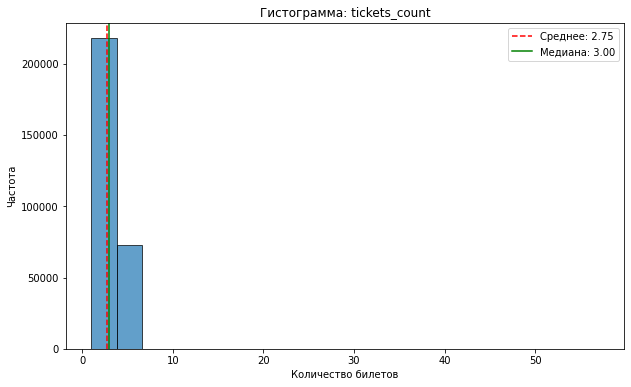

In [28]:
#Гистограмма для количества билетов
plt.figure(figsize=(10, 6))
plt.hist(df['tickets_count'], bins=20, edgecolor='black', alpha=0.7)
plt.axvline(df['tickets_count'].mean(), color='red', linestyle='--', label=f'Среднее: {df["tickets_count"].mean():.2f}')
plt.axvline(df['tickets_count'].median(), color='green', linestyle='-', label=f'Медиана: {df["tickets_count"].median():.2f}')
plt.title(f'Гистограмма: {"tickets_count"}')
plt.xlabel('Количество билетов')
plt.ylabel('Частота')
plt.legend()
plt.show()

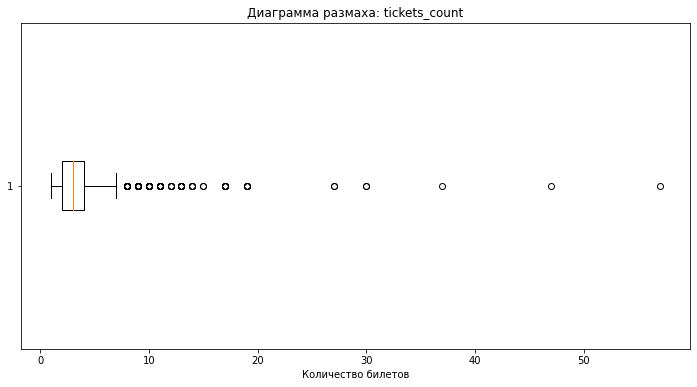

In [29]:
#Диаграмма размаха для количества билетов
plt.figure(figsize=(12, 6))
plt.boxplot(df['tickets_count'], vert=False)
plt.title(f'Диаграмма размаха: {"tickets_count"}')
plt.xlabel('Количество билетов')
plt.show()

Распределение близко к симметричному. В среднем покупают 2-4 билета. Среднее - 2.75, медиана -3. Есть выбросы (макс.значение - 57)

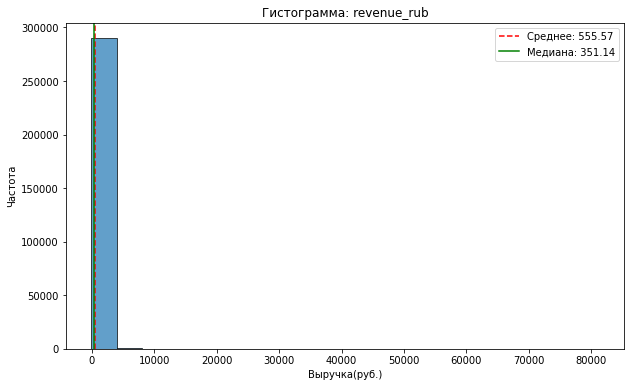

In [30]:
#Гистограмма для выручки
plt.figure(figsize=(10, 6))
plt.hist(df['revenue_rub'], bins=20, edgecolor='black', alpha=0.7)
plt.axvline(df['revenue_rub'].mean(), color='red', linestyle='--', label=f'Среднее: {df["revenue_rub"].mean():.2f}')
plt.axvline(df['revenue_rub'].median(), color='green', linestyle='-', label=f'Медиана: {df["revenue_rub"].median():.2f}')
plt.title(f'Гистограмма: {"revenue_rub"}')
plt.xlabel('Выручка(руб.)')
plt.ylabel('Частота')
plt.legend()
plt.show()

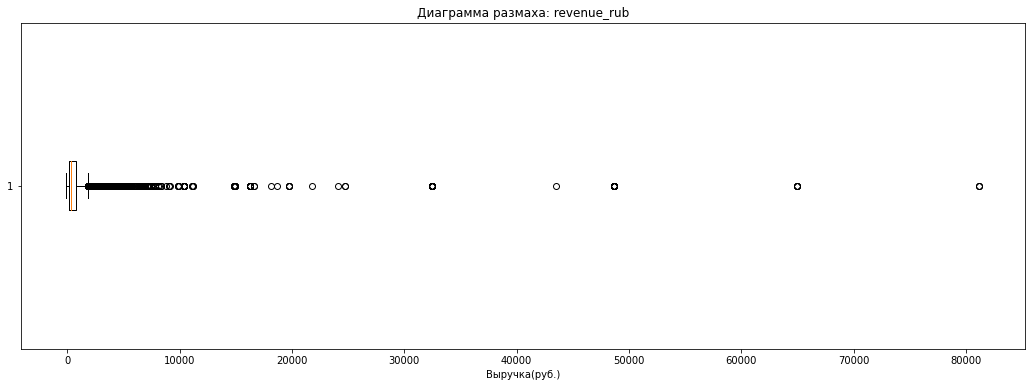

In [31]:
#Диаграмма размаха для выручки
plt.figure(figsize=(18, 6))
plt.boxplot(df['revenue_rub'], vert=False)
plt.title(f'Диаграмма размаха: {"revenue_rub"}')
plt.xlabel('Выручка(руб.)')
plt.show()

Асимметрия вправо. В среднем люди тратят от 114 до 802 руб., среднее - 556, медиана - 351.
Есть выбросы (мин.значение - -91руб, макс.значение - 81174 руб.), что может говорить о возвратах и оптовых покупках.

In [32]:
#Считаем выбросы через IQR
Q1 = df['tickets_count'].quantile(0.25)
Q3 = df['tickets_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound_tickets = Q1 - 1.5 * IQR
upper_bound_tickets = Q3 + 1.5 * IQR
print(lower_bound_tickets, upper_bound_tickets)

-1.0 7.0


In [33]:
#Считаем выбросы через IQR
Q1 = df['revenue_rub'].quantile(0.25)
Q3 = df['revenue_rub'].quantile(0.75)
IQR = Q3 - Q1
lower_bound_revenue = Q1 - 1.5 * IQR
upper_bound_revenue = Q3 + 1.5 * IQR
print(round(lower_bound_revenue,2), round(upper_bound_revenue, 2))

-918.15 1834.17


Вопрос. Тут я нашла выбросы с помощью межквартильного размаха, но ведь с т.з. бизнес логики "нормальные" результаты от -1 до 7 для билетов и -918 до 1834 для выручки это какая-то ерунда. Что в таких случаях делаем и как интерпретируем, подскажи, пожалуйста.

In [34]:
#99-й перцентиль
percentile_99 = df['revenue_rub'].quantile(0.99)
df_filtered = df[df['revenue_rub'] <= percentile_99]

In [35]:
len(df_filtered)

287786

In [36]:
len(df)-len(df_filtered)

2825

Пропуски содержатся только в столбце days_since_prev.
Пропуски типа MNAR, можно оставить, как есть.
Данные столбца days_since_prev преобразованы в int, данные столбца tickets_count оптимизированы.
В категориальных данных дубликатов нет.
Распределение близко к симметричному. В среднем покупают 2-4 билета. Среднее - 2.75, медиана -3. Есть выбросы (макс.значение - 57)
Асимметрия вправо. В среднем люди тратят от 114 до 802 руб., среднее - 556, медиана - 351. Есть выбросы (мин.значение - -91руб, макс.значение - 81174 руб.), что может говорить о возвратах и оптовых покупках.
Датафрейм отфильтрован по 99 перцентилю столбца revenue_rub.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [37]:
df_filtered = df_filtered.sort_values('order_dt')

users = df_filtered.groupby('user_id').agg({
    'order_dt': ['first', 'last'],
    'device_type_canonical': 'first',
    'region_name': 'first', 
    'service_name': 'first',
    'event_type_main': 'first',
    'order_id': 'count',
    'revenue_rub': 'mean',
    'tickets_count': 'mean'
})

#Время между заказами
users[('time', 'mean')] = df_filtered.groupby('user_id')['order_dt'].diff().dt.days.groupby(df_filtered['user_id']).mean()

#Признаки
users['is_two'] = (users[('order_id', 'count')] >= 2).astype(int)
users['is_five'] = (users[('order_id', 'count')] >= 5).astype(int)

#Округление
users[('revenue_rub', 'mean')] = users[('revenue_rub', 'mean')].round(2)
users[('tickets_count', 'mean')] = users[('tickets_count', 'mean')].round(2)

users.head()

order_dt            device_type_canonical  \
                     first       last                 first   
user_id                                                       
0002849b70a3ce2 2024-08-20 2024-08-20                mobile   
0005ca5e93f2cf4 2024-07-23 2024-10-06                mobile   
000898990054619 2024-07-13 2024-10-23                mobile   
00096d1f542ab2b 2024-08-15 2024-08-15               desktop   
000a55a418c128c 2024-09-29 2024-10-15                mobile   

                          region_name   service_name event_type_main order_id  \
                                first          first           first    count   
user_id                                                                         
0002849b70a3ce2    Каменевский регион   Край билетов           театр        1   
0005ca5e93f2cf4    Каменевский регион      Мой билет        выставки        2   
000898990054619  Североярская область    Лови билет!          другое        3   
00096d1f542ab2b    Каменевский регион   Край билетов           театр        1   
000a55a418c128c      Поленовский край  Лучшие билеты           театр        2   

                revenue_rub tickets_count  time is_two is_five  
                       mean          mean  mean                 
user_id                                                         
0002849b70a3ce2     1521.94          4.00   NaN      0       0  
0005ca5e93f2cf4      774.01          3.00  75.0      1       0  
000898990054619      767.21          2.67  51.0      1       0  
00096d1f542ab2b      917.83          4.00   NaN      0       0  
000a55a418c128c       61.31          1.50  16.0      1       0

In [38]:
len(users)

21854

In [39]:
#Копия users
users_copy=users.copy()

#Общее число пользователей в выборке
len(users_copy)

21854

In [40]:
#Средняя выручка с одного заказа
round(users_copy[('revenue_rub', 'mean')].mean(), 2)

544.4

In [41]:
#Доля пользователей, совершивших 2 и более заказа
round(users_copy['is_two'].mean()*100, 2)

61.71

In [42]:
#Доля пользователей, совершивших 5 и более заказов
round(users_copy['is_five'].mean()*100, 2)

29.01

In [43]:
#Статистика по заказам
users_copy[('order_id', 'count')].describe()

count    21854.000000
mean        13.168573
std        121.674800
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10181.000000
Name: (order_id, count), dtype: float64

In [44]:
#Статистика по билетам
users_copy[('tickets_count', 'mean')].describe()

count    21854.000000
mean         2.743136
std          0.913090
min          1.000000
25%          2.000000
50%          2.750000
75%          3.080000
max         11.000000
Name: (tickets_count, mean), dtype: float64

In [45]:
#Статистика по времени между заказами
users_copy[('time', 'mean')].describe()

count    13486.000000
mean        15.877577
std         22.271930
min          0.000000
25%          1.000000
50%          8.071429
75%         20.500000
max        148.000000
Name: (time, mean), dtype: float64

Есть выброс в статистике по заказам - 10181. Требуется отфильтровать по 99 или 95 перцентилю.

In [46]:
#95 перцентиль по заказам
orders95=users_copy[('order_id', 'count')].quantile(0.95)

#Фильтрация по 95 перцентилю по заказам (при фильтрации по 99 перцентилю макс.кол. заказов было 152)
users_filtered_95=users_copy[users_copy[('order_id', 'count')] <= orders95]

users_filtered_95.head(20)

order_dt            device_type_canonical  \
                     first       last                 first   
user_id                                                       
0002849b70a3ce2 2024-08-20 2024-08-20                mobile   
0005ca5e93f2cf4 2024-07-23 2024-10-06                mobile   
000898990054619 2024-07-13 2024-10-23                mobile   
00096d1f542ab2b 2024-08-15 2024-08-15               desktop   
000a55a418c128c 2024-09-29 2024-10-15                mobile   
000cf0659a9f40f 2024-06-20 2024-06-21                mobile   
00147c9209d45d3 2024-06-25 2024-06-25                mobile   
0018ecd8a38a51b 2024-07-25 2024-07-25                mobile   
00199a573901564 2024-06-17 2024-06-17                mobile   
001e7037d013f0f 2024-07-04 2024-09-29                mobile   
0020c5654c92ec1 2024-07-02 2024-07-02                mobile   
00245c702bc343e 2024-08-31 2024-10-25               desktop   
0028d17a676f8c8 2024-09-07 2024-10-06               desktop   
002b75ca606ba46 2024-07-08 2024-10-16               desktop   
002bf837be989ea 2024-08-20 2024-08-20                mobile   
002ec276eee9b0b 2024-07-10 2024-10-31                mobile   
0033403583a55ed 2024-06-19 2024-09-17                mobile   
0033e08fba8d0c9 2024-09-03 2024-09-03                mobile   
00345f897f95a34 2024-06-02 2024-10-23                mobile   
003764d5339bb45 2024-10-24 2024-10-24                mobile   

                          region_name        service_name event_type_main  \
                                first               first           first   
user_id                                                                     
0002849b70a3ce2    Каменевский регион        Край билетов           театр   
0005ca5e93f2cf4    Каменевский регион           Мой билет        выставки   
000898990054619  Североярская область         Лови билет!          другое   
00096d1f542ab2b    Каменевский регион        Край билетов           театр   
000a55a418c128c      Поленовский край       Лучшие билеты           театр   
000cf0659a9f40f   Широковская область         Лови билет!        концерты   
00147c9209d45d3    Каменевский регион             Облачко        концерты   
0018ecd8a38a51b     Медовская область  Билеты без проблем           спорт   
00199a573901564    Каменевский регион  Билеты без проблем        концерты   
001e7037d013f0f   Златопольский округ           Мой билет          другое   
0020c5654c92ec1    Каменевский регион  Билеты без проблем        концерты   
00245c702bc343e  Североярская область             Облачко         стендап   
0028d17a676f8c8     Ветренский регион         Быстробилет        концерты   
002b75ca606ba46    Каменевский регион         Быстробилет        концерты   
002bf837be989ea     Боровлянский край  Билеты без проблем        концерты   
002ec276eee9b0b   Широковская область           Мой билет        концерты   
0033403583a55ed    Каменевский регион  Билеты без проблем          другое   
0033e08fba8d0c9  Горицветская область             Облачко        концерты   
00345f897f95a34      Лесодальний край         Тебе билет!        концерты   
003764d5339bb45  Североярская область       Лучшие билеты        концерты   

                order_id revenue_rub tickets_count       time is_two is_five  
                   count        mean          mean       mean                 
user_id                                                                       
0002849b70a3ce2        1     1521.94          4.00        NaN      0       0  
0005ca5e93f2cf4        2      774.01          3.00  75.000000      1       0  
000898990054619        3      767.21          2.67  51.000000      1       0  
00096d1f542ab2b        1      917.83          4.00        NaN      0       0  
000a55a418c128c        2       61.31          1.50  16.000000      1       0  
000cf0659a9f40f       13     1175.81          3.31   0.083333      1       1  
00147c9209d45d3        2      352.94          1.50   0.000000      1       0  
0018ec

In [47]:
print(len(users_copy))
print(len(users_filtered_95))
print(len(users_copy)-len(users_filtered_95))
print(round(1093/21854*100, 2))

21854
20761
1093
5.0


In [48]:
#Новая статистика по заказам
users_filtered_95[('order_id', 'count')].describe()

count    20761.000000
mean         4.049564
std          5.113359
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max         31.000000
Name: (order_id, count), dtype: float64

In [49]:
#Новая статистика по билетам
users_filtered_95[('tickets_count', 'mean')].describe()

count    20761.000000
mean         2.743603
std          0.934549
min          1.000000
25%          2.000000
50%          2.750000
75%          3.150000
max         11.000000
Name: (tickets_count, mean), dtype: float64

In [50]:
#Новая статистика по времени между заказами
users_filtered_95[('time', 'mean')].describe()

count    12393.000000
mean        17.085837
std         22.839250
min          0.000000
25%          1.000000
50%          9.500000
75%         22.250000
max        148.000000
Name: (time, mean), dtype: float64

In [51]:
#Новая средняя выручка с одного заказа
round(users_filtered_95[('revenue_rub', 'mean')].mean(), 2)

546.68

In [52]:
#Новая доля пользователей, совершивших 2 и более заказа
round(users_filtered_95['is_two'].mean()*100, 2)

59.69

In [53]:
#Новая доля пользователей, совершивших 5 и более заказов
round(users_filtered_95['is_five'].mean()*100, 2)

25.27

После изучения статистических показателей по общему числу заказов, среднему числу билетов и среднему количеству дней между заказами пользователей были обнаружены выбросы в статистике по заказам (макс.знач.- 10181). Данные по клиентам отфильтрованы по 95 перцентилю. Было отфильтровано 5% данных, в итоговом датафрейме 20761 строка.\
Средняя выручка на один заказ - 546ю68 руб.\
Около 60% пользователей совершили более одного заказа, из них 25% - более 5 заказов.\
Большинство людей делают 1-2 заказа, среднее число заказов - 4.\
Среднее количество билетов на 1 заказ - 2.7.\
У постоянных клиентов в среднем проходит 9-22 дня между покупками.


---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [54]:
users_filtered_95.columns=['first_date', 'last_date', 'device', 'region', 'partner', 'genre', 
                 'orders_count', 'avg_revenue', 'avg_tickets', 'avg_time', 'is_two', 'is_five']

In [55]:
#Тип мероприятия в первой покупке
genre_first=users_filtered_95.groupby('genre').size().sort_values(ascending=False)
genre_first_ratio=round(genre_first/len(users_filtered_95)*100)
print(genre_first)
print(genre_first_ratio)

genre
концерты    9196
другое      5177
театр       4056
стендап     1067
спорт        768
выставки     401
ёлки          96
dtype: int64
genre
концерты    44.0
другое      25.0
театр       20.0
стендап      5.0
спорт        4.0
выставки     2.0
ёлки         0.0
dtype: float64


In [56]:
#Тип устройства, с которого совершена первая покупка
device_first=users_filtered_95.groupby('device').size().sort_values(ascending=False)
device_first_ratio=round(device_first/len(users_filtered_95)*100)
print(device_first)
print(device_first_ratio)

device
mobile     17205
desktop     3556
dtype: int64
device
mobile     83.0
desktop    17.0
dtype: float64


In [57]:
#Регион проведения мероприятия из первого заказа
region_first=users_filtered_95.groupby('region').size().sort_values(ascending=False)
region_first_ratio=round(region_first/len(users_filtered_95)*100)
print(region_first.head(29))
print(region_first_ratio)

region
Каменевский регион           6773
Североярская область         3611
Широковская область          1184
Озернинский край              654
Малиновоярский округ          514
Травяная область              466
Шанырский регион              461
Светополянский округ          434
Речиновская область           420
Яблоневская область           398
Верхоречная область           373
Медовская область             358
Лугоградская область          345
Серебринская область          321
Тепляковская область          309
Солнечнореченская область     287
Солнечноземская область       276
Горицветская область          227
Глиногорская область          212
Зоринский регион              205
Лесодальний край              190
Заречная область              189
Речицкий регион               183
Каменноярский край            172
Ветренский регион             144
Травиницкий округ             126
Берёзовская область           110
Малиновая область             104
Каменноозёрный край           103
dtype: 

In [58]:
#Билетный оператор первого заказа
partner_first=users_filtered_95.groupby('partner').size().sort_values(ascending=False)
partner_first_ratio=round(partner_first/len(users_filtered_95)*100)
print(partner_first)
print(partner_first_ratio)

partner
Билеты без проблем        4965
Мой билет                 2849
Лови билет!               2711
Билеты в руки             2430
Облачко                   2116
Весь в билетах            1224
Лучшие билеты             1136
Прачечная                  550
Край билетов               437
Дом культуры               341
Яблоко                     307
Тебе билет!                298
Городской дом культуры     209
За билетом!                201
Мир касс                   197
Быстробилет                155
Show_ticket                155
Выступления.ру              92
Восьмёрка                   81
Быстрый кассир              54
Crazy ticket!               44
Росбилет                    38
Радио ticket                35
Телебилет                   28
Реестр                      27
Цвет и билет                21
Шоу начинается!             18
КарандашРУ                  14
Кино билет                   9
Вперёд!                      7
Билет по телефону            6
Тех билет                    3


Данные распределены неравномерно, есть явные точки входа, куда следуюет направить дополнительные маркетинговые усилия.\
Самый популярный жанр - концерты (44%, 9196 пользователей), менее популярны, но весомы жанры другое и театр (25% и 20%).\
Чаще всего пользователи используют мобильную версию сервиса (83%, 17205 пользователей).\
Лольяные пользователи чаще всего делают заказы в Каменевском регионе (33%, 6773 пользователя) и Североярской области (17%, 3611 пользователей).\
Самый популярный для покупи билетов портал - Билеты без проблем (24%, 4965 пользователей), следующие по популярности партнеры: Мой билет(14%, 2849 пользователей), Лови билет! (13%, 2711 пользователей), Билеты в руки (12%, 2430 пользователей), Облачко (10%, 2116 пользователей)

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [59]:
#Датафрейм с пользователями, кто совершил больше 1 заказа
loyal_users=users_filtered_95[users_filtered_95['is_two']==1].copy()
print(len(users_filtered_95))
print(len(loyal_users))
print(round(len(loyal_users)/len(users_filtered_95)*100, 2))

20761
12393
59.69


In [60]:
#Тип мероприятия в первой покупке для пользователя, совершившего больше 1 покупки
genre_first_loyal=loyal_users.groupby('genre').size().sort_values(ascending=False)
genre_first_loyal_ratio=round(genre_first_loyal/len(loyal_users)*100)
print(genre_first_loyal)
print(genre_first_loyal_ratio)

genre
концерты    5547
другое      2986
театр       2504
стендап      633
спорт        417
выставки     252
ёлки          54
dtype: int64
genre
концерты    45.0
другое      24.0
театр       20.0
стендап      5.0
спорт        3.0
выставки     2.0
ёлки         0.0
dtype: float64


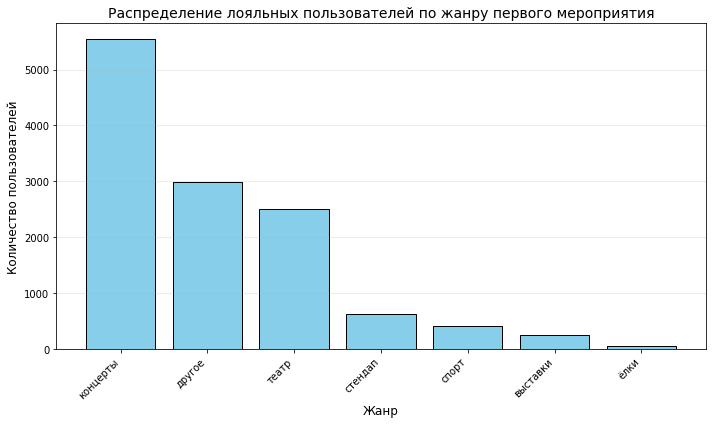

In [61]:
plt.figure(figsize=(10, 6))
plt.bar(genre_first_loyal.index, genre_first_loyal.values, color='skyblue', edgecolor='black')
plt.title('Распределение лояльных пользователей по жанру первого мероприятия', fontsize=14)
plt.xlabel('Жанр', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
#Тип устройства, с которого совершена первая покупка, для пользователя, совершившего больше 1 покупки
device_first_loyal=loyal_users.groupby('device').size().sort_values(ascending=False)
device_first_loyal_ratio=round(device_first_loyal/len(loyal_users)*100)
print(device_first_loyal)
print(device_first_loyal_ratio)

device
mobile     10181
desktop     2212
dtype: int64
device
mobile     82.0
desktop    18.0
dtype: float64


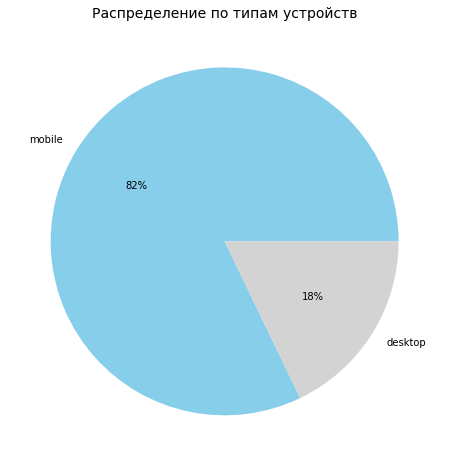

In [63]:
plt.figure(figsize=(8, 8))
plt.pie(device_first_loyal.values, labels=device_first_loyal.index, autopct='%1.0f%%', 
        colors=['skyblue', 'lightgray'])
plt.title('Распределение по типам устройств', fontsize=14)
plt.show()

In [64]:
#Регион проведения мероприятия из первого заказа для пользователя, совершившего больше 1 покупки
region_first_loyal=loyal_users.groupby('region').size().sort_values(ascending=False)
region_first_loyal_ratio=round(region_first_loyal/len(loyal_users)*100)
print(region_first_loyal.head(29))
print(region_first_loyal_ratio)

region
Каменевский регион           4109
Североярская область         2248
Широковская область           750
Озернинский край              352
Шанырский регион              297
Малиновоярский округ          283
Травяная область              278
Светополянский округ          277
Речиновская область           259
Яблоневская область           231
Верхоречная область           215
Медовская область             206
Лугоградская область          188
Тепляковская область          178
Серебринская область          174
Солнечнореченская область     164
Солнечноземская область       160
Горицветская область          145
Зоринский регион              118
Заречная область              117
Речицкий регион               116
Глиногорская область          111
Лесодальний край              106
Каменноярский край             93
Ветренский регион              89
Травиницкий округ              70
Берёзовская область            69
Каменноозёрный край            61
Малиновая область              59
dtype: 

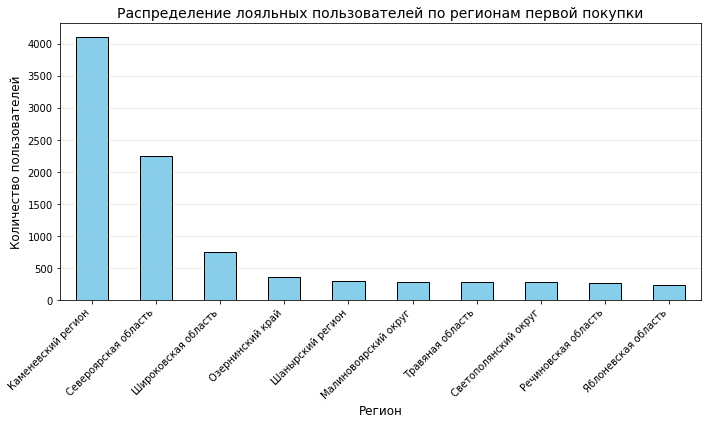

In [65]:
region_first_loyal.head(10).plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')
plt.title('Распределение лояльных пользователей по регионам первой покупки', fontsize=14)
plt.xlabel('Регион', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
#Билетный оператор первого заказа для пользователя, совершившего больше 1 покупки
partner_first_loyal=loyal_users.groupby('partner').size().sort_values(ascending=False)
partner_first_loyal_ratio=round(partner_first_loyal/len(loyal_users)*100)
print(partner_first_loyal)
print(partner_first_loyal_ratio)

partner
Билеты без проблем        2912
Мой билет                 1687
Лови билет!               1613
Билеты в руки             1476
Облачко                   1273
Весь в билетах             747
Лучшие билеты              677
Прачечная                  332
Край билетов               279
Дом культуры               215
Тебе билет!                176
Яблоко                     159
Мир касс                   123
Городской дом культуры     120
За билетом!                118
Show_ticket                100
Быстробилет                 89
Выступления.ру              56
Восьмёрка                   54
Быстрый кассир              45
Crazy ticket!               30
Росбилет                    24
Реестр                      21
Радио ticket                14
Телебилет                   13
Цвет и билет                13
Кино билет                   5
КарандашРУ                   5
Билет по телефону            5
Шоу начинается!              5
Вперёд!                      4
Лимоны                       1


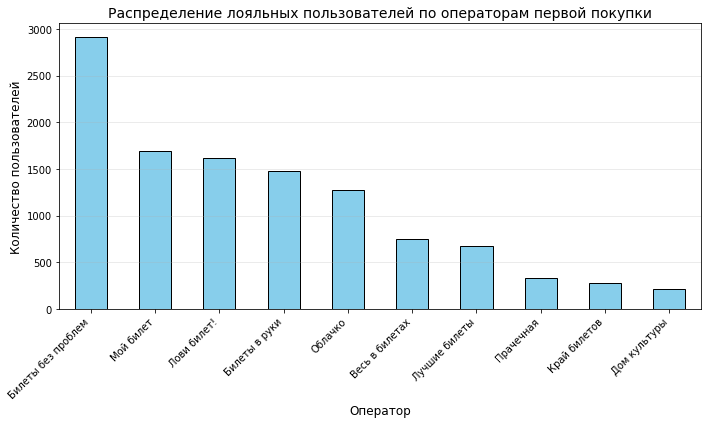

In [67]:
partner_first_loyal.head(10).plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')
plt.title('Распределение лояльных пользователей по операторам первой покупки', fontsize=14)
plt.xlabel('Оператор', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Данные распределены неравномерно, есть явные точки входа, куда следуюет направить дополнительные маркетинговые усилия.
Самый популярный жанр - концерты (45%, 5547 пользователей), менее популярны, но весомы жанры другое и театр (24% и 20%).
Чаще всего пользователи используют мобильную версию сервиса (82%, 10181 пользователь).
Лольяные пользователи чаще всего делают заказы в Каменевском регионе (33%, 4109 пользователей) и Североярской области (18%Б 2248 пользователей).
Самый популярный для покупи билетов портал - Билеты без проблем (23%, 2912 пользователей), следующие по популярности партнеры: Мой билет(14%, 1687 пользователей), Лови билет! (13%, 1613 пользователей), Билеты в руки (12%, 1476 пользователей), Облачко (10%, 1273 пользователя)

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Гипотеза 1:\
Доля повторных покупок в категории "концерты" - 60%, в категории "спорт" - 54%, гипотеза не подтверждается, пользователи, пришедшие на концерты, возвращаются чаще, чем те, кто начал со спорта.

Гипотеза 2:\
Для проверки гипотезы взяла регионы, в которых было более 100 продаж. (больше 90% регионов)
Средняя доля повторных покупок в 5 регионах с самыми большими продажами составляет 59%, в 5 регионах с самыми низкими - 59%, средняя доля по всем регионам - 59%, разброс долей от 54% до 63%. Показатель 63% встречается как у регионов с большими продажами (Широковская), так и со средними (Шанырский, Горицветская, Речицкий, Березовская). Гипотеза не подтверждается, нет связи между активностью региона и долей повторных заказов.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [68]:
users_filtered_95.head()

,first_date,last_date,device,region,partner,genre,orders_count,avg_revenue,avg_tickets,avg_time,is_two,is_five
user_id,,,,,,,,,,,,
0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.94,4.00,NaN,0,0
0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.01,3.00,75.0,1,0
000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.21,2.67,51.0,1,0
00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.83,4.00,NaN,0,0
000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.31,1.50,16.0,1,0


In [69]:
#Средняя выручка с билета для пользователей с 1 заказом
avg_revenue_1 = users_filtered_95[users_filtered_95['orders_count'] == 1]['avg_revenue']

#Средняя выручка с билета для пользователей с 2 и более заказами
avg_revenue_2=users_filtered_95[users_filtered_95['orders_count'] >= 2]['avg_revenue']

print(avg_revenue_1.describe())
print(avg_revenue_2.describe())

count    8368.000000
mean      545.295638
std       519.514095
min       -10.770000
25%       132.070000
50%       378.030000
75%       830.317500
max      2628.420000
Name: avg_revenue, dtype: float64
count    12393.000000
mean       547.615087
std        378.948532
min         -5.380000
25%        260.760000
50%        494.490000
75%        762.060000
max       2628.420000
Name: avg_revenue, dtype: float64


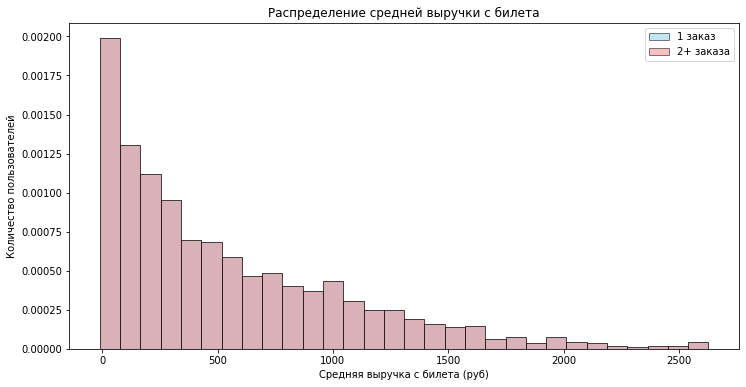

In [70]:
plt.figure(figsize=(12, 6))

plt.hist(avg_revenue_1, bins=30, alpha=0.5, label='1 заказ', color='skyblue', edgecolor='black', density=True)
plt.hist(avg_revenue_1, bins=30, alpha=0.5, label='2+ заказа', color='lightcoral', edgecolor='black', density=True)

plt.xlabel('Средняя выручка с билета (руб)')
plt.ylabel('Количество пользователей')
plt.title('Распределение средней выручки с билета')
plt.legend()
plt.show()

Пользователи с 1 заказом концентрируются в диапазоне 132-830 рублей, чаще всего пользователь тратит 378 рублей.\
Пользователи с 2+ заказами концентрируются в диапазоне 261-762 рубля, чаще всего пользователь тратит 492 рублей.\
У лояльных пользователей более равномерное распределение средней суммы заказа.\
Лояльные пользователи покупают более дорогие билеты. Соответственно, дешевые билеты редко конвертируются в повторные продажи.\
Маркетинговые усилия следует направить на пользователей, купивших билеты за 260-800 рублей (стратегия удержания для клиентов, совершивших более 2 заказов и стратегия вовлечения для пользователей, совершивших 1 заказ).

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [71]:
#Средняя выручка с билета для пользователей с 2-4 заказами
avg_revenue_2_4 = users_filtered_95[(users_filtered_95['orders_count'] >= 2) & (users_filtered_95['orders_count'] <= 4)]['avg_revenue']

#Средняя выручка с билета для пользователей с 5 и более заказами
avg_revenue_5 = users_filtered_95[users_filtered_95['orders_count'] >= 5]['avg_revenue']

print(avg_revenue_2_4.describe())
print(avg_revenue_5.describe())

count    7147.000000
mean      551.572363
std       420.197703
min        -5.380000
25%       218.425000
50%       471.270000
75%       798.550000
max      2628.420000
Name: avg_revenue, dtype: float64
count    5246.000000
mean      542.223807
std       314.113529
min         0.000000
25%       316.590000
50%       514.580000
75%       728.307500
max      2299.870000
Name: avg_revenue, dtype: float64


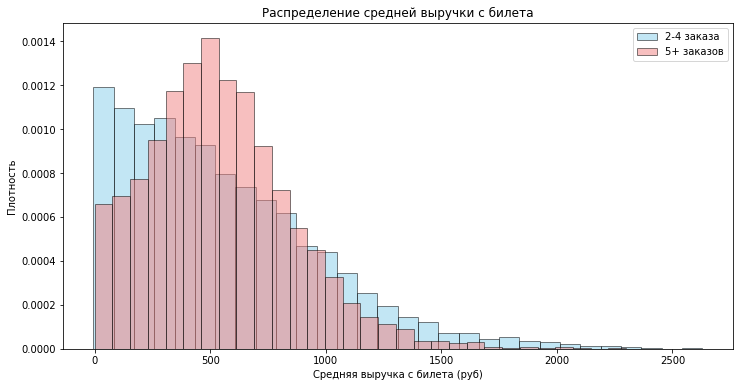

In [72]:
plt.figure(figsize=(12, 6))

plt.hist(avg_revenue_2_4, 
         bins=30, alpha=0.5, label='2-4 заказа', color='skyblue', edgecolor='black', density=True)
plt.hist(avg_revenue_5, 
         bins=30, alpha=0.5, label='5+ заказов', color='lightcoral', edgecolor='black', density=True)

plt.xlabel('Средняя выручка с билета (руб)')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки с билета')
plt.legend()
plt.show()

Пользователи с 2-4 заказами концентрируются в диапазоне 218-799 рублей, чаще всего пользователь тратит 471 рублей.\
Пользователи с 5+ заказами концентрируются в диапазоне 317-728 рубля, чаще всего пользователь тратит 515 рублей.\
У суперлояльных пользователей более равномерное распределение средней суммы заказа.\
Чем больше заказов совершил пользователь, тем выше его типичный чек и выше минимальная граница трат, но ниже разброс в поведении.\
Рекомендуется разработать целевые предложения после оформления 4-го заказа для перехода из сегмента 2-4 в 5+.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [73]:
#Пользователи с 1-2, 2-3, 3-5 и 5+ билетами
users_1_2 = users_filtered_95[(users_filtered_95['avg_tickets'] >= 1) & (users_filtered_95['avg_tickets'] < 2)]

users_2_3 = users_filtered_95[(users_filtered_95['avg_tickets'] >= 2) & (users_filtered_95['avg_tickets'] < 3)]

users_3_5 = users_filtered_95[(users_filtered_95['avg_tickets'] >= 3) & (users_filtered_95['avg_tickets'] < 5)]

users_5 = users_filtered_95[users_filtered_95['avg_tickets'] >= 5]

#Количество, доли
print(f"1-2 билета: {len(users_1_2)}")
print(f"Доля повторных покупок: {users_1_2['is_two'].mean() * 100:.2f}%")
print(f"Доля от общего количества пользователей: {len(users_1_2)/len(users_filtered_95) * 100:.2f}%")

print(f"2-3 билета: {len(users_2_3)}")
print(f"Доля повторных покупок: {users_2_3['is_two'].mean() * 100:.2f}%")
print(f"Доля от общего количества пользователей: {len(users_2_3)/len(users_filtered_95) * 100:.2f}%")


print(f"3-5 билетов: {len(users_3_5)}")
print(f"Доля повторных покупок: {users_3_5['is_two'].mean() * 100:.2f}%")
print(f"Доля от общего количества пользователей: {len(users_3_5)/len(users_filtered_95) * 100:.2f}%")


print(f"5+ билетов: {len(users_5)}")
print(f"Доля повторных покупок: {users_5['is_two'].mean() * 100:.2f}%")
print(f"Доля от общего количества пользователей: {len(users_5)/len(users_filtered_95) * 100:.2f}%")


1-2 билета: 2415
Доля повторных покупок: 51.22%
Доля от общего количества пользователей: 11.63%
2-3 билета: 8759
Доля повторных покупок: 71.36%
Доля от общего количества пользователей: 42.19%
3-5 билетов: 8926
Доля повторных покупок: 53.57%
Доля от общего количества пользователей: 42.99%
5+ билетов: 661
Доля повторных покупок: 18.76%
Доля от общего количества пользователей: 3.18%


80% пользователей сконцентрированы в сегментах 2-3 и 3-5 билетов.\
Люди, которые покупают в среднем 2–3 билета за раз, с наибольшей вероятностью вернутся снова (доля повторных покупок 71%).\
Пользователи, покупающие более 5 билетов за раз составляют наименьшее количество и имеют низкий % возврата (19%), возможно, это связано с тем, что такое количество билетов покупается на компанию, а такие походы нерегулярны. Те же пользователи, которые возвращаются, скорее всего корпоративные клиенты.\

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [74]:
users_filtered_95['weekday'] = users_filtered_95['first_date'].dt.dayofweek

/tmp/ipykernel_48/3944253992.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  users_filtered_95['weekday'] = users_filtered_95['first_date'].dt.dayofweek


In [75]:
weekday_order_count = users_filtered_95.groupby('weekday')['orders_count'].count()
weekday_loyal = users_filtered_95.groupby('weekday')['is_two'].sum()
weekday_loyal_part = round(weekday_loyal/weekday_order_count*100, 2)
print(weekday_order_count)
print(weekday_loyal_part)

weekday
0    2820
1    3025
2    2960
3    3027
4    3166
5    3122
6    2641
Name: orders_count, dtype: int64
weekday
0    61.60
1    60.00
2    60.95
3    58.28
4    58.65
5    60.38
6    57.97
dtype: float64


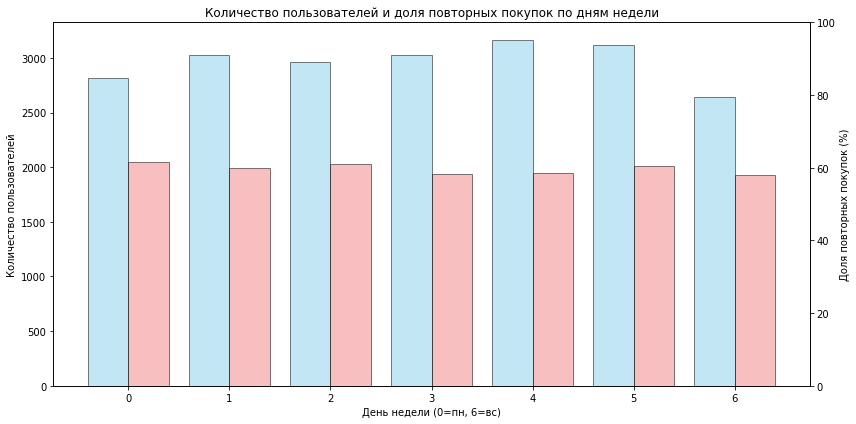

In [76]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(weekday_order_count.index - 0.2, weekday_order_count.values, 
        width=0.4, alpha=0.5, label='Количество пользователей', 
        color='skyblue', edgecolor='black')
ax1.set_xlabel('День недели (0=пн, 6=вс)')
ax1.set_ylabel('Количество пользователей')

ax2 = ax1.twinx()
ax2.bar(weekday_loyal_part.index + 0.2, weekday_loyal_part.values, 
        width=0.4, alpha=0.5, label='Доля повторных покупок', 
        color='lightcoral', edgecolor='black')
ax2.set_ylabel('Доля повторных покупок (%)')
ax2.set_ylim(0, 100)

plt.title('Количество пользователей и доля повторных покупок по дням недели')
plt.xticks(weekday_order_count.index)
fig.tight_layout()
plt.show()

День недели, в которую совершена первая покупка, значимо не влияет на вероятность возврата клиента. Разброс доли повторных покупок по дням недели очень маленький - 3.63 (61.60 - 57.97).

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [77]:
#Клиенты с 2-4 заказами (переменная с клиентами с 5+заказами уже сохранена выше)
users_2_4 = users_filtered_95[(users_filtered_95['orders_count'] >= 2) & (users_filtered_95['orders_count'] <= 4)]
avg_time_2_4 = users_2_4['avg_time']
avg_time_5plus = users_5['avg_time']

#Доли
print(f"2-4 заказа: {len(users_2_4['avg_time'])}")
print(f"Среднее количество дней между заказами: {users_2_4['avg_time'].mean():.2f}")

print(f"5+ заказов: {len(users_5['avg_time'])}")
print(f"Среднее количество дней между заказами: {users_5['avg_time'].mean():.2f}")

2-4 заказа: 7147
Среднее количество дней между заказами: 21.41
5+ заказов: 661
Среднее количество дней между заказами: 8.18


Чем меньше интервал между заказами, тем выше вероятность, что пользователь совершит много повторных заказов.
Интервал между заказами дает возможность спрогнозировать лояльность.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [78]:
users_filtered_95.head()

,first_date,last_date,device,region,partner,genre,orders_count,avg_revenue,avg_tickets,avg_time,is_two,is_five,weekday
user_id,,,,,,,,,,,,,
0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.94,4.00,NaN,0,0,1
0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.01,3.00,75.0,1,0,1
000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.21,2.67,51.0,1,0,5
00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.83,4.00,NaN,0,0,3
000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.31,1.50,16.0,1,0,6


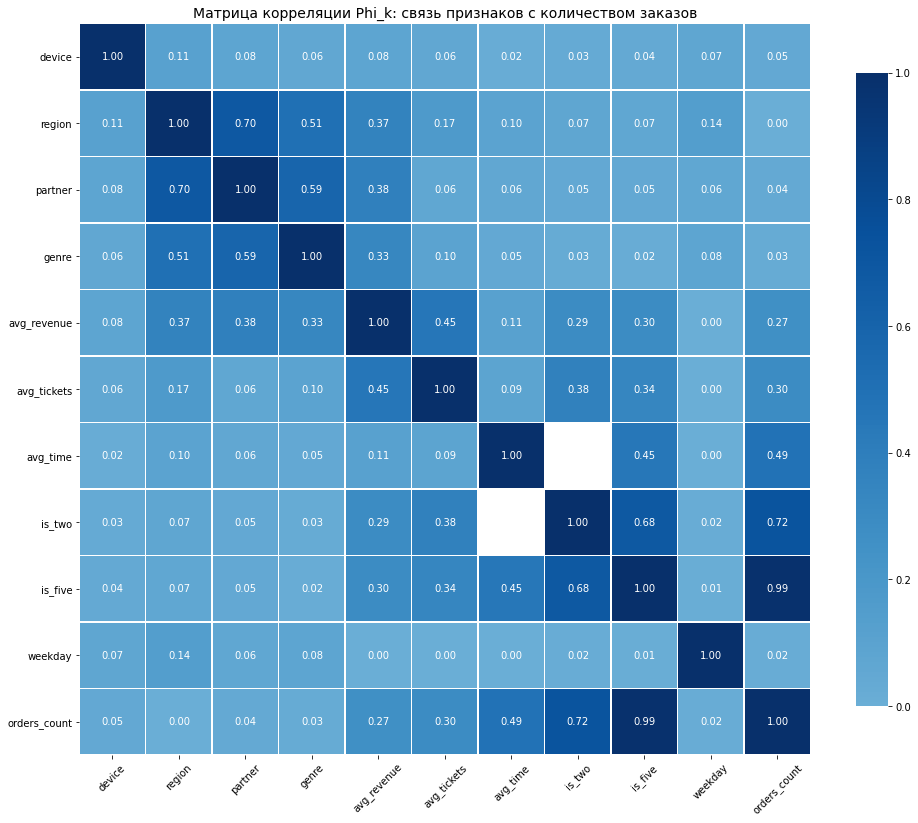

In [79]:
interval_cols = ['avg_revenue', 'avg_tickets', 'avg_time', 'weekday', 'orders_count']

phik_matrix = users_filtered_95[['device', 'region', 'partner', 'genre', 
            'avg_revenue', 'avg_tickets', 'avg_time',
            'is_two', 'is_five', 'weekday', 'orders_count']].phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(14, 12))
sns.heatmap(phik_matrix, 
            annot=True,
            cmap='Blues',
            center=0,
            vmin=0, vmax=1,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляции Phi_k: связь признаков с количеством заказов', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [80]:
print(phik_matrix)

                device    region   partner     genre  avg_revenue  \
device        1.000000  0.112567  0.082449  0.062421     0.078286   
region        0.112567  1.000000  0.695268  0.505651     0.366310   
partner       0.082449  0.695268  1.000000  0.586653     0.384992   
genre         0.062421  0.505651  0.586653  1.000000     0.334880   
avg_revenue   0.078286  0.366310  0.384992  0.334880     1.000000   
avg_tickets   0.057630  0.172526  0.063779  0.096970     0.453180   
avg_time      0.019960  0.098357  0.056737  0.054559     0.111944   
is_two        0.034673  0.071508  0.046887  0.030936     0.293860   
is_five       0.040583  0.067433  0.052898  0.022399     0.295455   
weekday       0.073946  0.141419  0.062855  0.082750     0.000000   
orders_count  0.051313  0.000000  0.039255  0.031110     0.265566   

              avg_tickets  avg_time    is_two   is_five   weekday  \
device           0.057630  0.019960  0.034673  0.040583  0.073946   
region           0.172526  0.0983

Наиболее сильная связь с признаками is_five (0.986) и is_two (0.720), что логично, ведь они напрямую отражают количество заказов. Среди прочих признаков наибольшее влияние оказывает avg_time (0.491), что тоже логично: чем чаще оформляются заказы, тем больше заказов. Остальные признаки (region, partner, genre, device, weekday) практически не показывают связи с лояльностью пользователей.

In [81]:
users_filtered_95['segment'] = pd.cut(users_filtered_95['orders_count'], bins=[0, 1, 4, 100], labels=['1','2-4','5+'])
interval_cols = ['avg_revenue', 'avg_tickets', 'avg_time', 'weekday', 'orders_count']
seg_2_4 = users_filtered_95[users_filtered_95['segment'] == '2-4']
seg_5 = users_filtered_95[users_filtered_95['segment'] == '5+']
phi_2_4 = seg_2_4[['device', 'region', 'partner', 'genre', 
            'avg_revenue', 'avg_tickets', 'avg_time',
            'is_two', 'is_five', 'weekday', 'orders_count']].phik_matrix(interval_cols=interval_cols)
phi_5 = seg_5[['device', 'region', 'partner', 'genre', 
            'avg_revenue', 'avg_tickets', 'avg_time',
            'is_two', 'is_five', 'weekday', 'orders_count']].phik_matrix(interval_cols=interval_cols)

/tmp/ipykernel_48/3697363518.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  users_filtered_95['segment'] = pd.cut(users_filtered_95['orders_count'], bins=[0, 1, 4, 100], labels=['1','2-4','5+'])
/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:82: UserWarning: Not enough unique value for variable is_five for analysis 1. Dropping this column
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:82: UserWarning: Not enough unique value for variable is_two for analysis 1. Dropping this column
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:82: UserWarning: Not enough unique value for variable is_five for analysis 1. Dropping this column
  warnings.warn(
/opt/conda/lib/python3.9/site

In [82]:
print(phi_2_4['orders_count'])
print(phi_5['orders_count'])

device          0.009083
region          0.000000
partner         0.047400
genre           0.000000
avg_revenue     0.108758
avg_tickets     0.369364
avg_time        0.386634
weekday         0.000000
orders_count    1.000000
Name: orders_count, dtype: float64
device          0.038735
region          0.067496
partner         0.068467
genre           0.051952
avg_revenue     0.163305
avg_tickets     0.115503
avg_time        0.716974
weekday         0.000000
orders_count    1.000000
Name: orders_count, dtype: float64


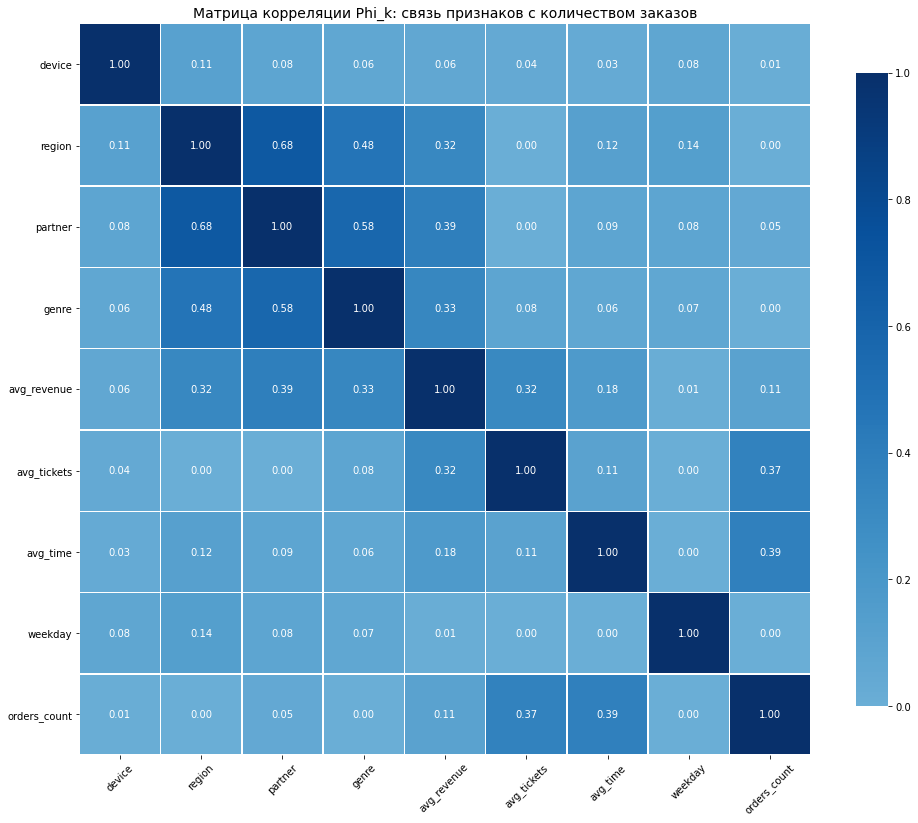

In [83]:
plt.figure(figsize=(14, 12))
sns.heatmap(phi_2_4, 
            annot=True,
            cmap='Blues',
            center=0,
            vmin=0, vmax=1,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляции Phi_k: связь признаков с количеством заказов', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

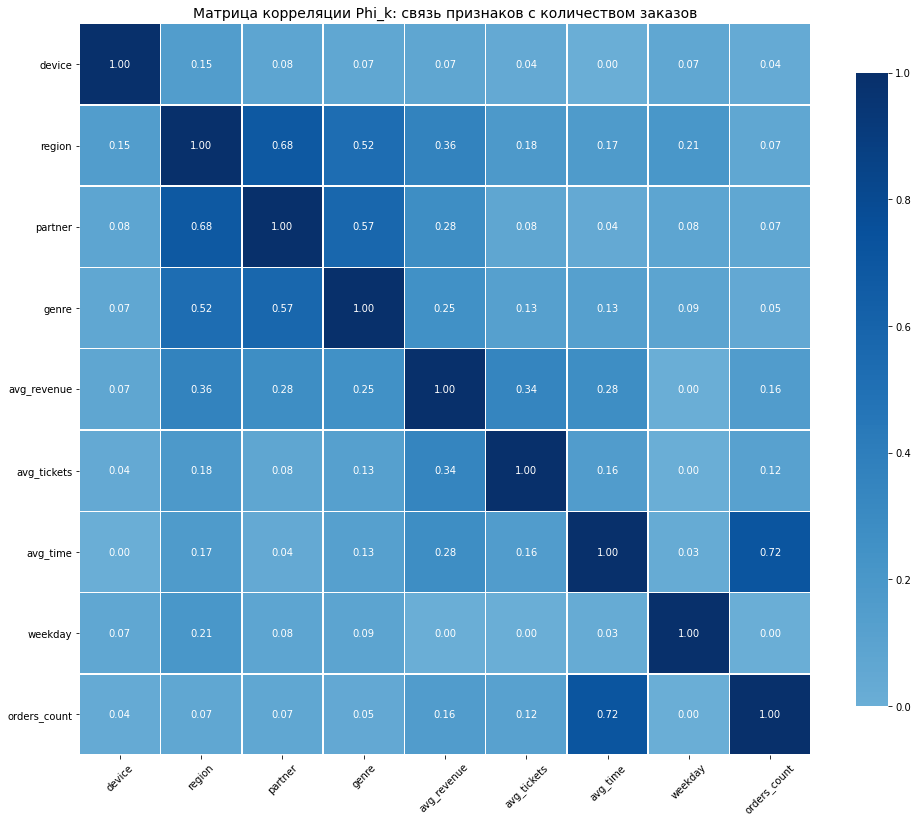

In [84]:
plt.figure(figsize=(14, 12))
sns.heatmap(phi_5, 
            annot=True,
            cmap='Blues',
            center=0,
            vmin=0, vmax=1,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляции Phi_k: связь признаков с количеством заказов', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Наиболее сильная связь с количеством заказов наблюдается у признака avg_time: в сегменте пользователей с 5+ заказами очень сильная связь (0.717). Признак avg_tickets более важен для сегмента 2-4 заказа и показывает умеренную связь(0.369). Географические и демографические признаки (region, partner, genre, device, weekday) демонстрируют крайне слабую связь во всех сегментах.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

В ходе работы был проанализирован датасет Яндекс Афиши (290 611 строк). Пропуски в столбце days_since_prev оставлены как есть (тип MNAR). После преобразования типов данных и фильтрации выбросов по 95-му перцентилю числа заказов итоговая выборка составила 20 761 пользователя. 

Анализ показал, что 60% пользователей совершили более одного заказа, 25% - более пяти. Средняя выручка на заказ - 547 рублей, среднее число билетов - 2,7. Наиболее популярный жанр - концерты (44%), основное устройство - мобильное (83%), лидирующий регион - Каменевский (33%).

Факторы, связанные с возвратом пользователей:\
покупка 2–3 билетов за раз дает долю повторных заказов 71%\
интервал между заказами позволяет спрогнозировать количество заказов (чем меньше времени между заказами, тем больше заказов)\
средний чек лояльных пользователей (492 руб.) выше, чем у разовых (378 руб.): пользователи, покупающие более дешевые билеты, реже возвращаются\
день недели первого заказа, регион и партнер значимо не влияют на возвращаемость\
корреляционный анализ подтвердил: самый сильный признак - avg_time (0,491 в общем сегменте и 0,717 среди пользователей с 5+ заказами), тогда как region, partner, genre, device и weekday практически не связаны с количеством заказов.

Рекомендации заказчику:\
сфокусироваться на сокращении интервалов между заказами через триггерные коммуникации через 7–14 дней после покупки\ стимулировать формат покупки 2–3 билетов\
направить усилия на сегменты с чеком 260–800 рублей\
для перехода пользователей из сегмента 2–4 заказа в 5+ разработать целевые предложения после четвертого заказа.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**